In [1]:
!git clone https://github.com/Deeptixx/ceam_task_1.git

Cloning into 'ceam_task_1'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 148 (delta 4), reused 144 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 2.39 MiB | 14.56 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [2]:
import os
import numpy as np
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-06-12 12:19:48.328457: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781266788.479070      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781266788.524364      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781266788.866008      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781266788.866049      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781266788.866052      58 computation_placer.cc:177] computation placer alr

In [3]:
data_dir = '/kaggle/working/ceam_task_1/dataset'
classes = ['phone', 'book', 'headphones', 'calculator', 'clock']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
image_paths = []
labels = []
for class_name in classes:
    class_dir = os.path.join(data_dir, class_name)
    for img_file in os.listdir(class_dir):
        if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_idx[class_name])
print(f"Total images: {len(image_paths)}")
print(f"Class distribution: {np.bincount(labels)}")

Total images: 125
Class distribution: [25 25 25 25 25]


In [4]:
images = []
for img_path in image_paths:
    img = keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = keras.preprocessing.image.img_to_array(img)
    images.append(img_array)
images = np.array(images)
labels = np.array(labels)
print(f"Images shape: {images.shape}")  #(125,224,224,3)
print(f"Labels shape: {labels.shape}")  #(125,)
images = images / 255.0 #normalizing pixel values

Images shape: (125, 224, 224, 3)
Labels shape: (125,)


In [5]:
# 70% train 15% val 15% test
train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, random_state=SEED, stratify=labels
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"\nTrain class distribution: {np.bincount(train_labels)}")
print(f"Val class distribution: {np.bincount(val_labels)}")
print(f"Test class distribution: {np.bincount(test_labels)}")

Train: 87, Val: 19, Test: 19

Train class distribution: [17 18 17 17 18]
Val class distribution: [4 3 4 4 4]
Test class distribution: [4 4 4 4 3]


In [6]:
def create_baseline_model(dropout_rate=0.5):
    model = models.Sequential([
        layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', 
                      input_shape=(224, 224, 3)),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(5, activation='softmax')
    ])
    
    return model
model = create_baseline_model(dropout_rate=0.5)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781266863.632995      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781266863.638955      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
base_model = create_baseline_model(dropout_rate=0.5)
initial_weights = base_model.get_weights()

In [9]:
model_bs16 = create_baseline_model(dropout_rate=0.5)
model_bs16.set_weights(initial_weights)

model_bs16.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bs16 = model_bs16.fit(
    train_images,
    train_labels,
    batch_size=16,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=0
)

test_loss_bs16, test_acc_bs16 = model_bs16.evaluate(
    test_images, test_labels, verbose=0
)

print(f"Batch Size 16 Test Accuracy: {test_acc_bs16*100:.2f}%")

2026-06-12 12:21:57.110304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 12:21:57.253296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Batch Size 16 Test Accuracy: 73.68%


In [11]:
model_bs32 = create_baseline_model(dropout_rate=0.5)
model_bs32.set_weights(initial_weights)

model_bs32.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bs32 = model_bs32.fit(
    train_images,
    train_labels,
    batch_size=32,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=0
)

test_loss_bs32, test_acc_bs32 = model_bs32.evaluate(
    test_images, test_labels, verbose=0
)

print(f"Batch Size 32 Test Accuracy: {test_acc_bs32*100:.2f}%")

Batch Size 32 Test Accuracy: 68.42%


In [13]:
model_bs64 = create_baseline_model(dropout_rate=0.5)
model_bs64.set_weights(initial_weights)

model_bs64.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bs64 = model_bs64.fit(
    train_images,
    train_labels,
    batch_size=64,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=0
)

test_loss_bs64, test_acc_bs64 = model_bs64.evaluate(
    test_images, test_labels, verbose=0
)

print(f"Batch Size 64 Test Accuracy: {test_acc_bs64*100:.2f}%")

Batch Size 64 Test Accuracy: 63.16%


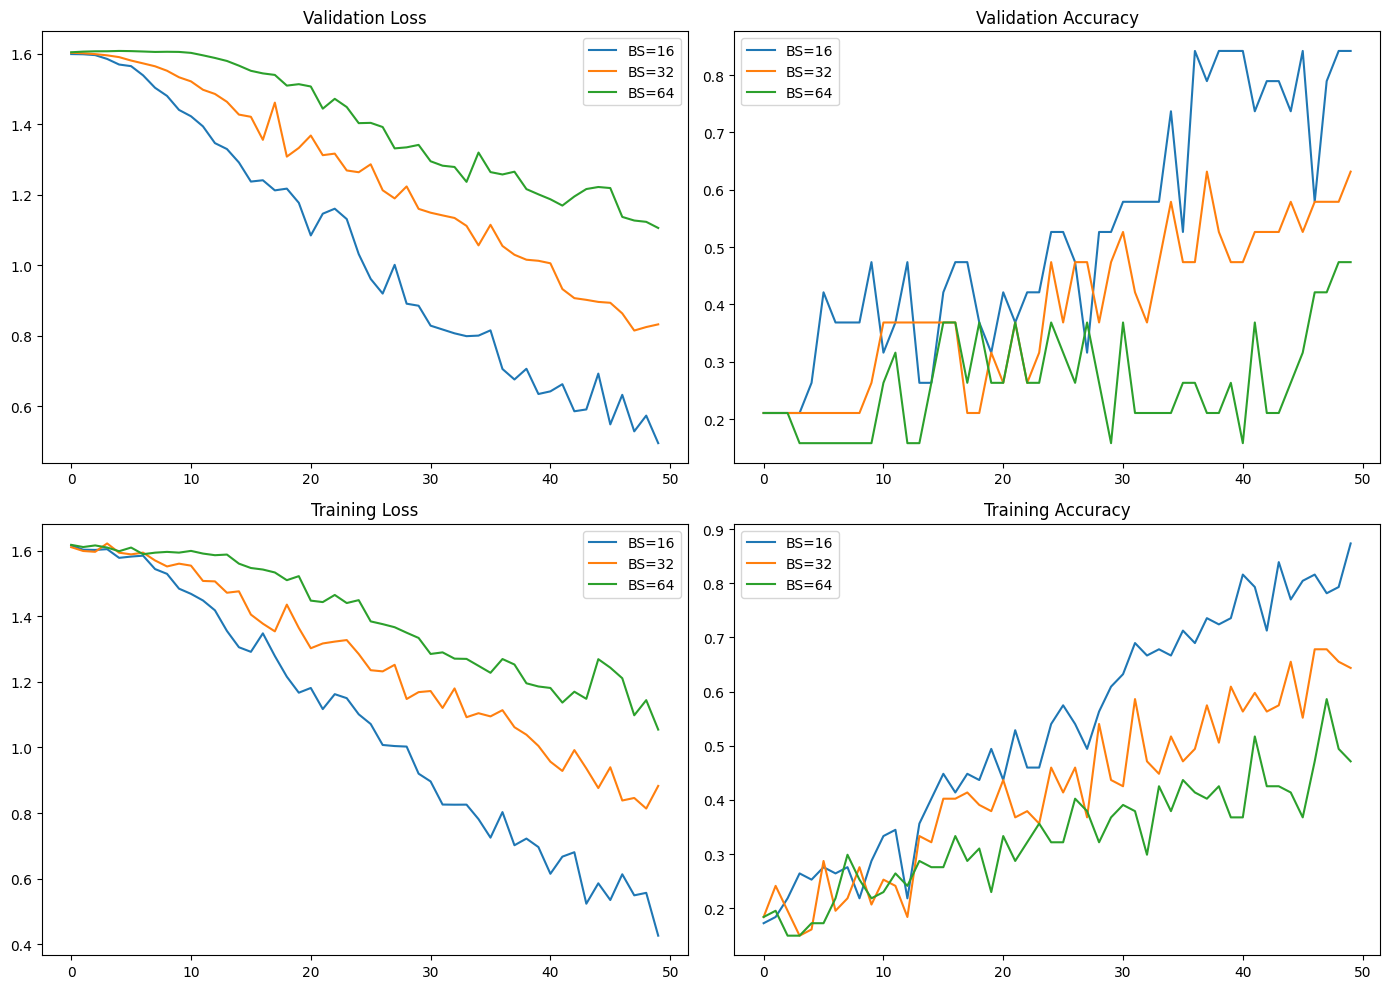

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation Loss
axes[0,0].plot(history_bs16.history['val_loss'], label='BS=16')
axes[0,0].plot(history_bs32.history['val_loss'], label='BS=32')
axes[0,0].plot(history_bs64.history['val_loss'], label='BS=64')
axes[0,0].set_title('Validation Loss')
axes[0,0].legend()

# Validation Accuracy
axes[0,1].plot(history_bs16.history['val_accuracy'], label='BS=16')
axes[0,1].plot(history_bs32.history['val_accuracy'], label='BS=32')
axes[0,1].plot(history_bs64.history['val_accuracy'], label='BS=64')
axes[0,1].set_title('Validation Accuracy')
axes[0,1].legend()

# Training Loss
axes[1,0].plot(history_bs16.history['loss'], label='BS=16')
axes[1,0].plot(history_bs32.history['loss'], label='BS=32')
axes[1,0].plot(history_bs64.history['loss'], label='BS=64')
axes[1,0].set_title('Training Loss')
axes[1,0].legend()

# Training Accuracy
axes[1,1].plot(history_bs16.history['accuracy'], label='BS=16')
axes[1,1].plot(history_bs32.history['accuracy'], label='BS=32')
axes[1,1].plot(history_bs64.history['accuracy'], label='BS=64')
axes[1,1].set_title('Training Accuracy')
axes[1,1].legend()

plt.tight_layout()
plt.show()